# 🔢 Q4 — Handwritten Digit Recognition
## Deep Learning | MNIST Dataset | TensorFlow / Keras

### 📌 Objective
Build a CNN to recognize handwritten digits (0–9) from the MNIST dataset.

### 📂 Dataset
- **MNIST** — 70,000 grayscale images (28×28 pixels)
- 60,000 training | 10,000 test | 10 classes (digits 0–9)

| Step | Description |
|------|-------------|
| 1 | Install & Import Libraries |
| 2 | Load Dataset |
| 3 | Data Exploration & Visualization |
| 4 | Preprocessing & Normalization |
| 5 | Build CNN Model |
| 6 | Compile & Train |
| 7 | Evaluate Model |
| 8 | Training Curves & Confusion Matrix |
| 9 | Predict on Sample Images |
| 10 | Save Model & Final Summary |

In [ ]:
# ─────────────────────────────────────────────────
# STEP 1: Import Required Libraries
# ─────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Sklearn metrics
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Check GPU
print(f"TensorFlow Version : {tf.__version__}")
print(f"Keras Version      : {keras.__version__}")
gpu_list = tf.config.list_physical_devices('GPU')
print(f"GPU Available      : {'Yes — ' + gpu_list[0].name if gpu_list else 'No (CPU)'}")

TensorFlow Version : 2.19.0
Keras Version      : 3.13.2
GPU Available      : No (CPU)


In [ ]:
# ─────────────────────────────────────────────────
# STEP 2: Load the MNIST Dataset
# Keras provides MNIST built-in — no download needed
# ─────────────────────────────────────────────────

(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.mnist.load_data()

print("✅ Dataset loaded successfully!")
print("─" * 45)
print(f"Training images  : {X_train_raw.shape}  → (samples, H, W)")
print(f"Training labels  : {y_train_raw.shape}")
print(f"Test images      : {X_test_raw.shape}")
print(f"Test labels      : {y_test_raw.shape}")
print("─" * 45)
print(f"Pixel value range: {X_train_raw.min()} – {X_train_raw.max()}")
print(f"Unique classes   : {np.unique(y_train_raw)}")
print(f"Data type        : {X_train_raw.dtype}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Dataset loaded successfully!
─────────────────────────────────────────────
Training images  : (60000, 28, 28)  → (samples, H, W)
Training labels  : (60000,)
Test images      : (10000, 28, 28)
Test labels      : (10000,)
─────────────────────────────────────────────
Pixel value range: 0 – 255
Unique classes   : [0 1 2 3 4 5 6 7 8 9]
Data type        : uint8


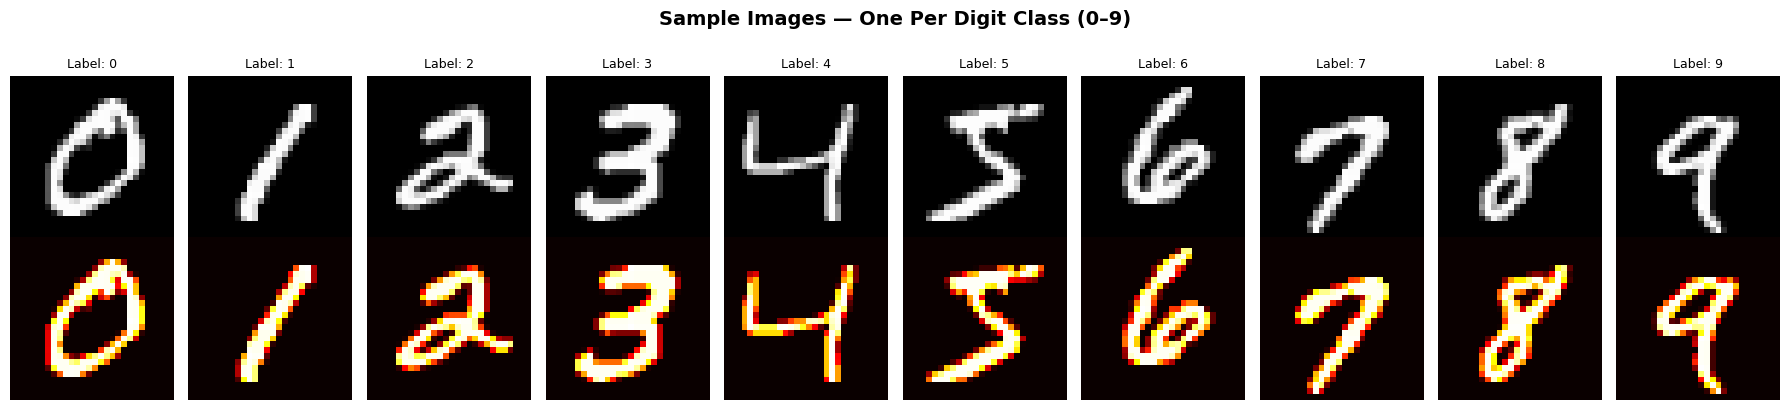

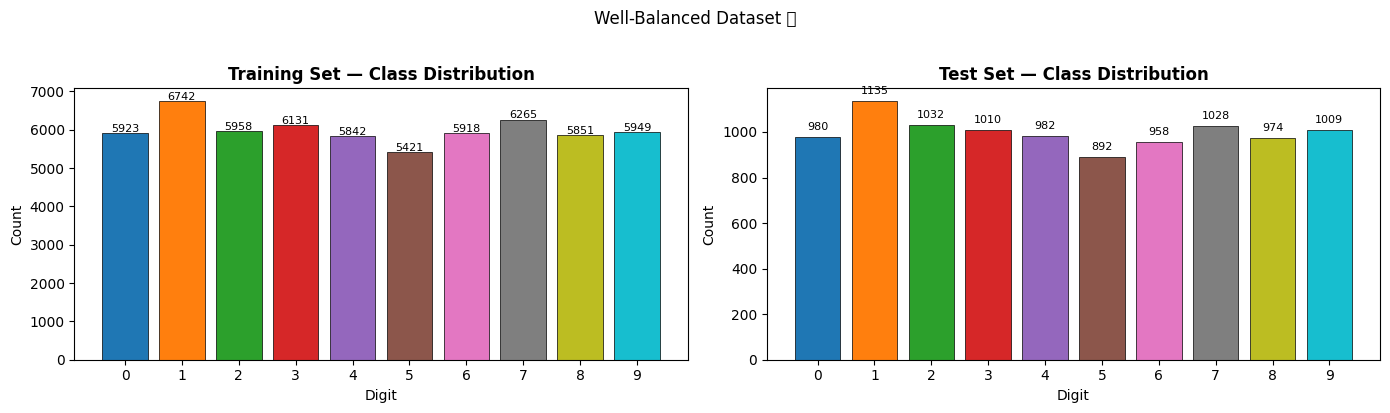

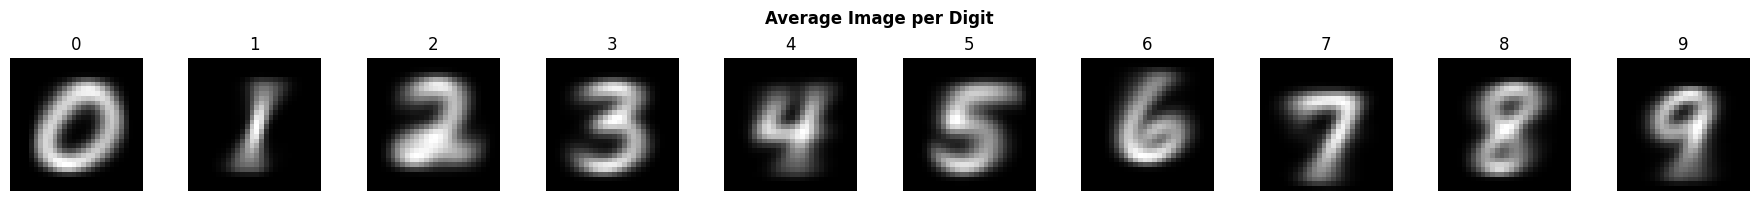

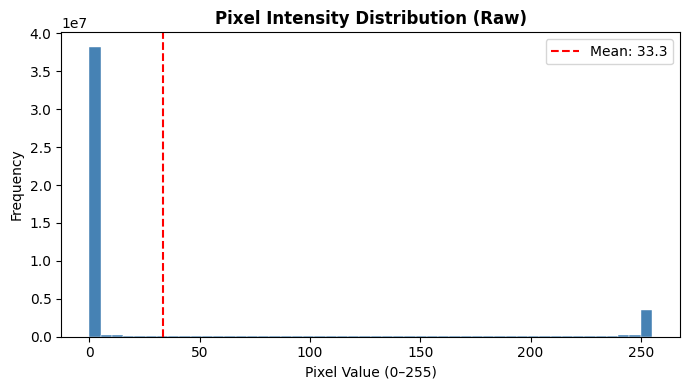

In [ ]:
# ─────────────────────────────────────────────────
# STEP 3A: Sample Images + Class Distribution
# ─────────────────────────────────────────────────

# --- One image per digit class ---
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Sample Images — One Per Digit Class (0–9)", fontsize=14, fontweight='bold', y=1.02)

for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    axes[0, digit].imshow(X_train_raw[idx], cmap='gray')
    axes[0, digit].set_title(f"Label: {digit}", fontsize=9)
    axes[0, digit].axis('off')
    axes[1, digit].imshow(X_train_raw[idx], cmap='hot')   # heat map view
    axes[1, digit].axis('off')

axes[0, 0].set_ylabel("Grayscale", fontsize=9)
axes[1, 0].set_ylabel("Heat Map",  fontsize=9)
plt.tight_layout(); plt.show()

# --- Class distribution bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts_raw, title in zip(
        axes,
        [y_train_raw, y_test_raw],
        ['Training Set', 'Test Set']):
    counts = pd.Series(counts_raw).value_counts().sort_index()
    ax.bar(counts.index, counts.values,
           color=plt.cm.tab10(np.linspace(0,1,10)),
           edgecolor='black', linewidth=0.5)
    ax.set_title(f'{title} — Class Distribution', fontweight='bold')
    ax.set_xlabel('Digit'); ax.set_ylabel('Count')
    ax.set_xticks(range(10))
    for i, v in enumerate(counts.values):
        ax.text(i, v + 30, str(v), ha='center', fontsize=8)

plt.suptitle('Well-Balanced Dataset ✅', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# --- Average image per digit ---
avg_images = np.array([X_train_raw[y_train_raw == d].mean(axis=0) for d in range(10)])
fig, axes  = plt.subplots(1, 10, figsize=(18, 2))
for d in range(10):
    axes[d].imshow(avg_images[d], cmap='gray')
    axes[d].set_title(f"{d}"); axes[d].axis('off')
fig.suptitle('Average Image per Digit', fontweight='bold'); plt.tight_layout(); plt.show()

# --- Pixel intensity histogram ---
all_pixels = X_train_raw.flatten()
plt.figure(figsize=(7, 4))
plt.hist(all_pixels, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
plt.axvline(all_pixels.mean(), color='red', linestyle='--',
            label=f'Mean: {all_pixels.mean():.1f}')
plt.title('Pixel Intensity Distribution (Raw)', fontweight='bold')
plt.xlabel('Pixel Value (0–255)'); plt.ylabel('Frequency')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# ─────────────────────────────────────────────────
# STEP 4: Preprocessing & Normalization
# ─────────────────────────────────────────────────

# 4A: Reshape — add channel dim required by CNN
#     (28, 28) → (28, 28, 1)
X_train = X_train_raw.reshape(-1, 28, 28, 1)
X_test  = X_test_raw.reshape(-1, 28, 28, 1)

# 4B: Normalize pixel values [0, 255] → [0.0, 1.0]
#     Smaller range → faster convergence + better gradient flow
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# 4C: One-Hot Encode labels
#     e.g., digit 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
NUM_CLASSES = 10
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

print("✅ Preprocessing complete!")
print("─" * 45)
print(f"X_train shape    : {X_train.shape}")
print(f"X_test  shape    : {X_test.shape}")
print(f"y_train shape    : {y_train.shape}  (one-hot)")
print(f"Pixel range now  : {X_train.min():.1f} – {X_train.max():.1f}")
print(f"Sample label [0] : {y_train[0]}  → digit {y_train_raw[0]}")

✅ Preprocessing complete!
─────────────────────────────────────────────
X_train shape    : (60000, 28, 28, 1)
X_test  shape    : (10000, 28, 28, 1)
y_train shape    : (60000, 10)  (one-hot)
Pixel range now  : 0.0 – 1.0
Sample label [0] : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  → digit 5


In [ ]:
# ─────────────────────────────────────────────────
# STEP 4: Preprocessing & Normalization
# ─────────────────────────────────────────────────

# 4A: Reshape — add channel dim required by CNN
#     (28, 28) → (28, 28, 1)
X_train = X_train_raw.reshape(-1, 28, 28, 1)
X_test  = X_test_raw.reshape(-1, 28, 28, 1)

# 4B: Normalize pixel values [0, 255] → [0.0, 1.0]
#     Smaller range → faster convergence + better gradient flow
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# 4C: One-Hot Encode labels
#     e.g., digit 3  →  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
NUM_CLASSES = 10
y_train = to_categorical(y_train_raw, NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  NUM_CLASSES)

print("✅ Preprocessing complete!")
print("─" * 45)
print(f"X_train shape    : {X_train.shape}")
print(f"X_test  shape    : {X_test.shape}")
print(f"y_train shape    : {y_train.shape}  (one-hot)")
print(f"Pixel range now  : {X_train.min():.1f} – {X_train.max():.1f}")
print(f"Sample label [0] : {y_train[0]}  → digit {y_train_raw[0]}")

✅ Preprocessing complete!
─────────────────────────────────────────────
X_train shape    : (60000, 28, 28, 1)
X_test  shape    : (10000, 28, 28, 1)
y_train shape    : (60000, 10)  (one-hot)
Pixel range now  : 0.0 – 1.0
Sample label [0] : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  → digit 5


In [ ]:
# ─────────────────────────────────────────────────
# STEP 5: Build CNN Model
#
# Architecture:
#   Input (28×28×1)
#   → Block 1: Conv2D(32)×2 + BatchNorm + MaxPool + Dropout(0.25)
#   → Block 2: Conv2D(64)×2 + BatchNorm + MaxPool + Dropout(0.25)
#   → Flatten → Dense(256) + BatchNorm + Dropout(0.5)
#   → Output:  Dense(10, softmax)
# ─────────────────────────────────────────────────

def build_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    """
    CNN for MNIST digit classification.
    Args:
        input_shape : (H, W, C) of a single image
        num_classes : number of digit classes (10)
    Returns:
        Compiled Keras Sequential model
    """
    model = models.Sequential(name='MNIST_CNN')

    # ── BLOCK 1: Low-level features — edges, strokes ──
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1_1'))
    model.add(layers.BatchNormalization(name='bn1_1'))   # stabilize activations
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', name='conv1_2'))
    model.add(layers.BatchNormalization(name='bn1_2'))
    model.add(layers.MaxPooling2D((2,2), name='pool1'))  # 28×28 → 14×14
    model.add(layers.Dropout(0.25, name='drop1'))        # regularization

    # ── BLOCK 2: High-level features — curves, digit shapes ──
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_1'))
    model.add(layers.BatchNormalization(name='bn2_1'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='conv2_2'))
    model.add(layers.BatchNormalization(name='bn2_2'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))  # 14×14 → 7×7
    model.add(layers.Dropout(0.25, name='drop2'))

    # ── CLASSIFIER HEAD ──
    model.add(layers.Flatten(name='flatten'))             # 7×7×64 = 3136
    model.add(layers.Dense(256, activation='relu', name='fc1'))
    model.add(layers.BatchNormalization(name='bn_fc'))
    model.add(layers.Dropout(0.5, name='drop_fc'))        # heavy dropout before output

    # ── OUTPUT: probabilities over 10 classes ──
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


model = build_cnn_model()
model.summary()

# Parameter summary table
print(f"\n{'Layer':<22} {'Output Shape':<22} {'Params':>8}")
print("─" * 55)
for i, layer in enumerate(model.layers):
    shape = model.layers[i].output.shape  # use symbolic tensor shape
    print(f"{layer.name:<22} {str(tuple(shape)):<22} {layer.count_params():>8,}")
print("─" * 55)
print(f"{'TOTAL':<44} {model.count_params():>8,}")

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_1 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_1 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1_2 (BatchNormalization)      │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_1 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2_2 (BatchNormalization)      │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc (BatchNormalization)      │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,426 (3.33 MB)

 Trainable params: 871,530 (3.32 MB)

 Non-trainable params: 896 (3.50 KB)


Layer                  Output Shape             Params
───────────────────────────────────────────────────────
conv1_1                (None, 28, 28, 32)          320
bn1_1                  (None, 28, 28, 32)          128
conv1_2                (None, 28, 28, 32)        9,248
bn1_2                  (None, 28, 28, 32)          128
pool1                  (None, 14, 14, 32)            0
drop1                  (None, 14, 14, 32)            0
conv2_1                (None, 14, 14, 64)       18,496
bn2_1                  (None, 14, 14, 64)          256
conv2_2                (None, 14, 14, 64)       36,928
bn2_2                  (None, 14, 14, 64)          256
pool2                  (None, 7, 7, 64)              0
drop2                  (None, 7, 7, 64)              0
flatten                (None, 3136)                  0
fc1                    (None, 256)             803,072
bn_fc                  (None, 256)               1,024
drop_fc                (None, 256)                   0
output  

In [ ]:
# ─────────────────────────────────────────────────
# STEP 6: Compile + Train
# ─────────────────────────────────────────────────
# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss', patience=3,        # ✅ reduced from 5 → 3
    restore_best_weights=True, verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=2, min_lr=1e-6, verbose=1)   # ✅ reduced from 3 → 2

# Train
EPOCHS     = 10          # ✅ reduced from 20 → 10 (EarlyStopping handles the rest)
BATCH_SIZE = 256         # ✅ increased from 128 → 256 (faster per epoch)

print(f"🚀 Training CNN on MNIST...")
print(f"   Max epochs  : {EPOCHS} | Batch: {BATCH_SIZE} | Val split: 10%")
print("─" * 60)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)





print("\n✅ Training complete!")

🚀 Training CNN on MNIST...
   Max epochs  : 10 | Batch: 256 | Val split: 10%
────────────────────────────────────────────────────────────
Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 159s 738ms/step - accuracy: 0.9338 - loss: 0.2178 - val_accuracy: 0.1050 - val_loss: 5.8423 - learning_rate: 0.0010
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 151s 716ms/step - accuracy: 0.9794 - loss: 0.0668 - val_accuracy: 0.8108 - val_loss: 0.6281 - learning_rate: 0.0010
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 201s 711ms/step - accuracy: 0.9852 - loss: 0.0477 - val_accuracy: 0.9877 - val_loss: 0.0442 - learning_rate: 0.0010
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 155s 736ms/step - accuracy: 0.9876 - loss: 0.0394 - val_accuracy: 0.9927 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 201s 730ms/step - accuracy: 0.9892 - loss: 0.0326 - val_accuracy: 0.9927 - val_loss: 0.0258 - learning_rate: 0.0010
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 199s 716ms/step - accuracy: 0.9912 - loss:

In [ ]:
# ─────────────────────────────────────────────────
# STEP 7: Evaluate on the Test Set
# ─────────────────────────────────────────────────

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print("📈 Test Set Performance")
print("─" * 45)
print(f"  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")

best_val_acc = max(history.history['val_accuracy'])
best_epoch   = np.argmax(history.history['val_accuracy']) + 1
print(f"  Best Val Acc  : {best_val_acc*100:.2f}%  (epoch {best_epoch})")

# Predictions
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

# Classification report
print("\n📋 Classification Report")
print("─" * 60)
print(classification_report(y_true, y_pred,
      target_names=[f"Digit {i}" for i in range(10)]))

📈 Test Set Performance
─────────────────────────────────────────────
  Test Accuracy : 99.51%
  Test Loss     : 0.0154
  Best Val Acc  : 99.42%  (epoch 8)

📋 Classification Report
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135
     Digit 2       1.00      1.00      1.00      1032
     Digit 3       0.99      1.00      0.99      1010
     Digit 4       1.00      0.99      1.00       982
     Digit 5       1.00      0.99      0.99       892
     Digit 6       1.00      0.99      1.00       958
     Digit 7       1.00      0.99      0.99      1028
     Digit 8       1.00      0.99      1.00       974
     Digit 9       0.99      0.99      0.99      1009

    accuracy                           1.00     10000
   macro avg       1.00      0.99      1.00     10000
weighted avg       1.00      1.00      1.00     10000



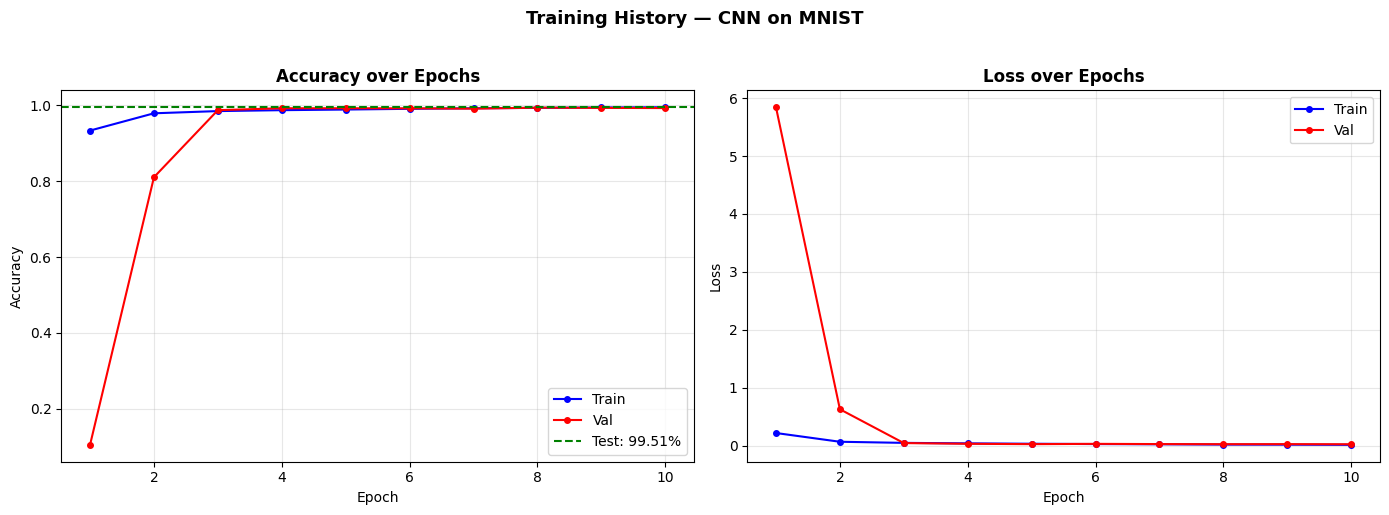

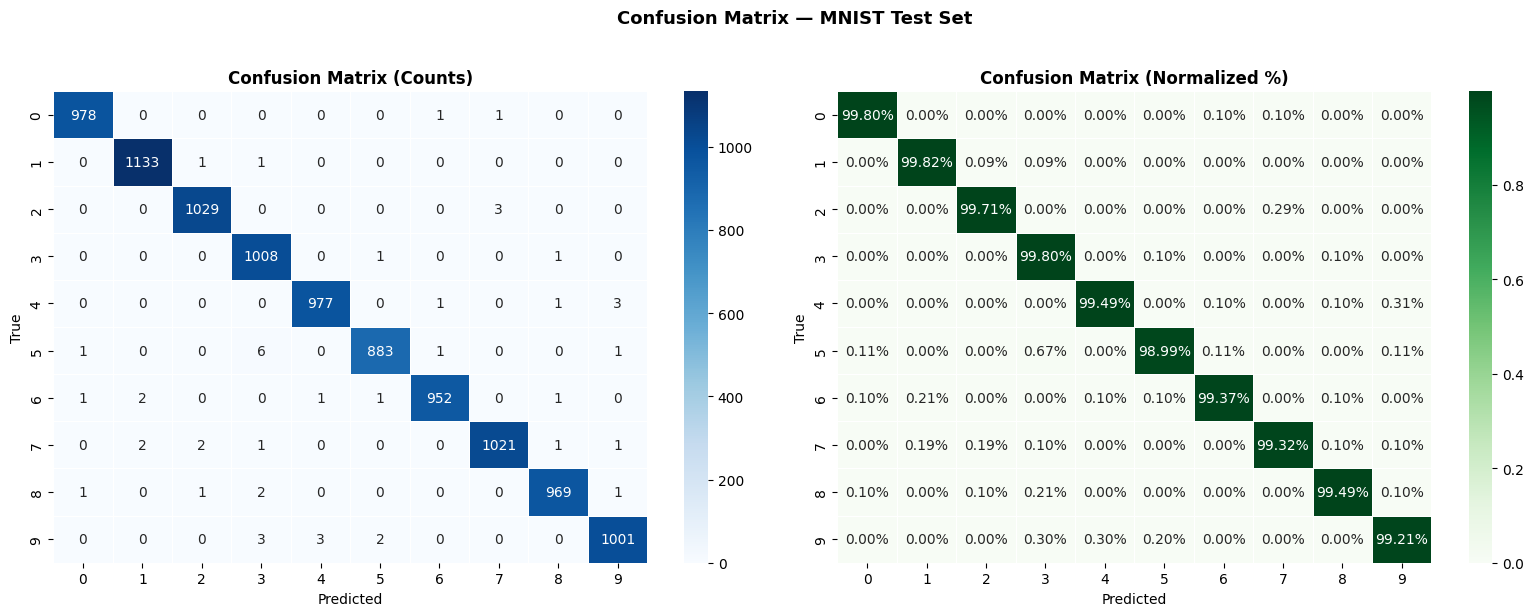


📊 Per-Class Test Accuracy:
   Digit 0: 99.80%
   Digit 1: 99.82%
   Digit 2: 99.71%
   Digit 3: 99.80%
   Digit 4: 99.49%
   Digit 5: 98.99%
   Digit 6: 99.37%
   Digit 7: 99.32%
   Digit 8: 99.49%
   Digit 9: 99.21%


In [ ]:
# ─────────────────────────────────────────────────
# STEP 8: Training History + Confusion Matrix
# ─────────────────────────────────────────────────

ep = range(1, len(history.history['loss']) + 1)

# --- Training curves ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ep, history.history['accuracy'],     'b-o', ms=4, label='Train')
axes[0].plot(ep, history.history['val_accuracy'], 'r-o', ms=4, label='Val')
axes[0].axhline(test_acc, color='green', linestyle='--',
                label=f'Test: {test_acc*100:.2f}%')
axes[0].set_title('Accuracy over Epochs', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, history.history['loss'],     'b-o', ms=4, label='Train')
axes[1].plot(ep, history.history['val_loss'], 'r-o', ms=4, label='Val')
axes[1].set_title('Loss over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Training History — CNN on MNIST', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Confusion matrix ---
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10),
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized %)', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.suptitle('Confusion Matrix — MNIST Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("\n📊 Per-Class Test Accuracy:")
for i, v in enumerate(cm_norm.diagonal()):
    print(f"   Digit {i}: {v*100:.2f}%")

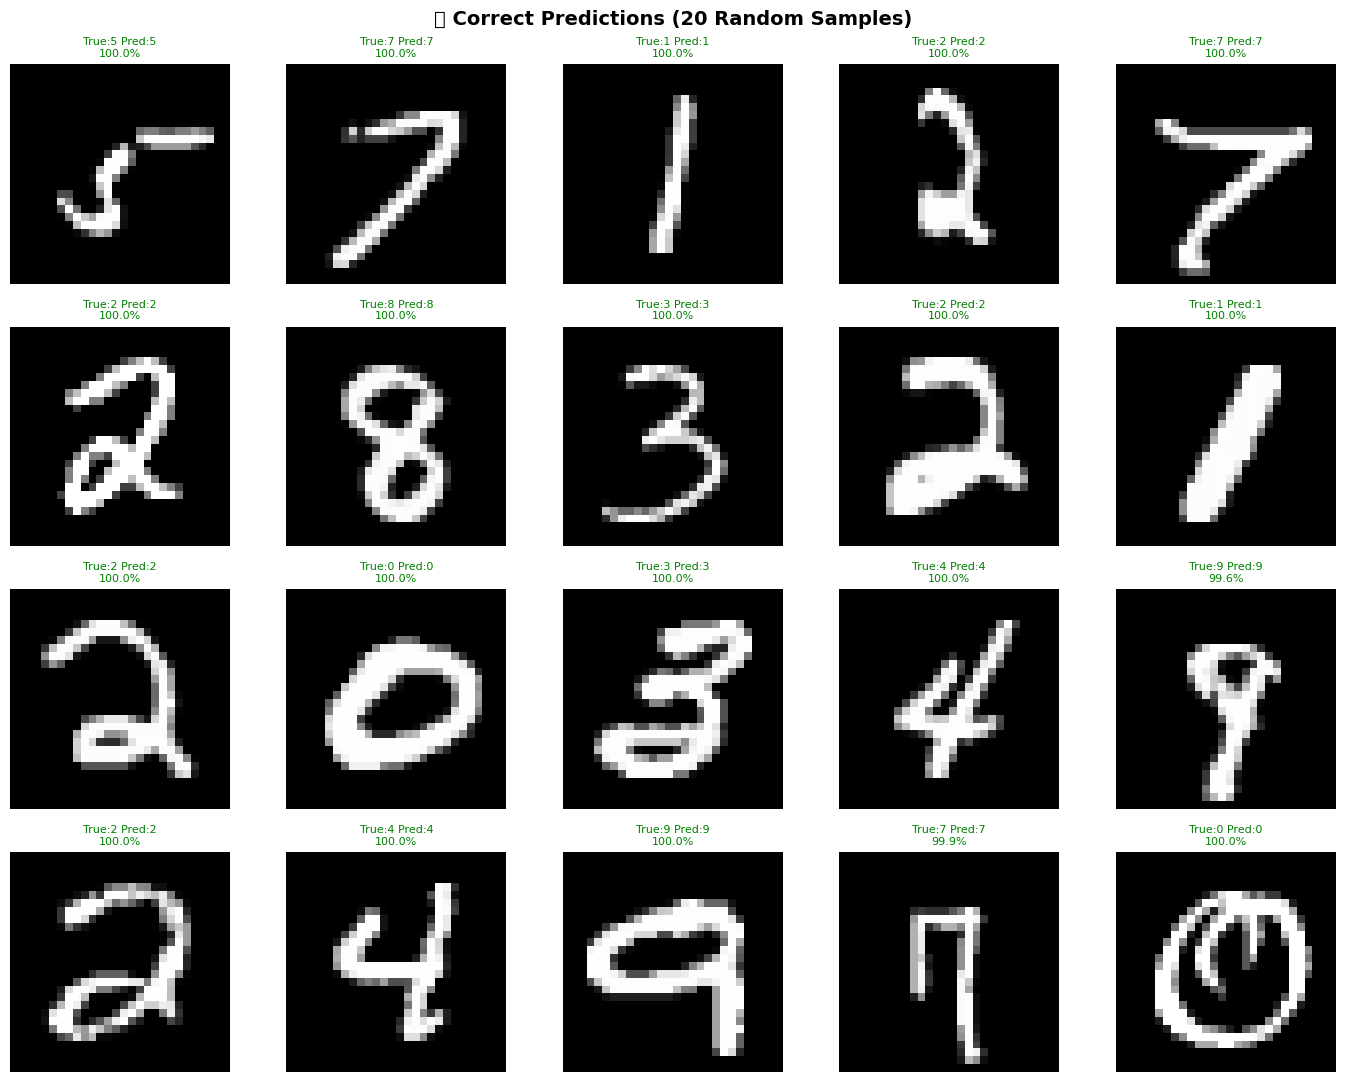

❌ Misclassified: 49 / 10000 (0.49%)


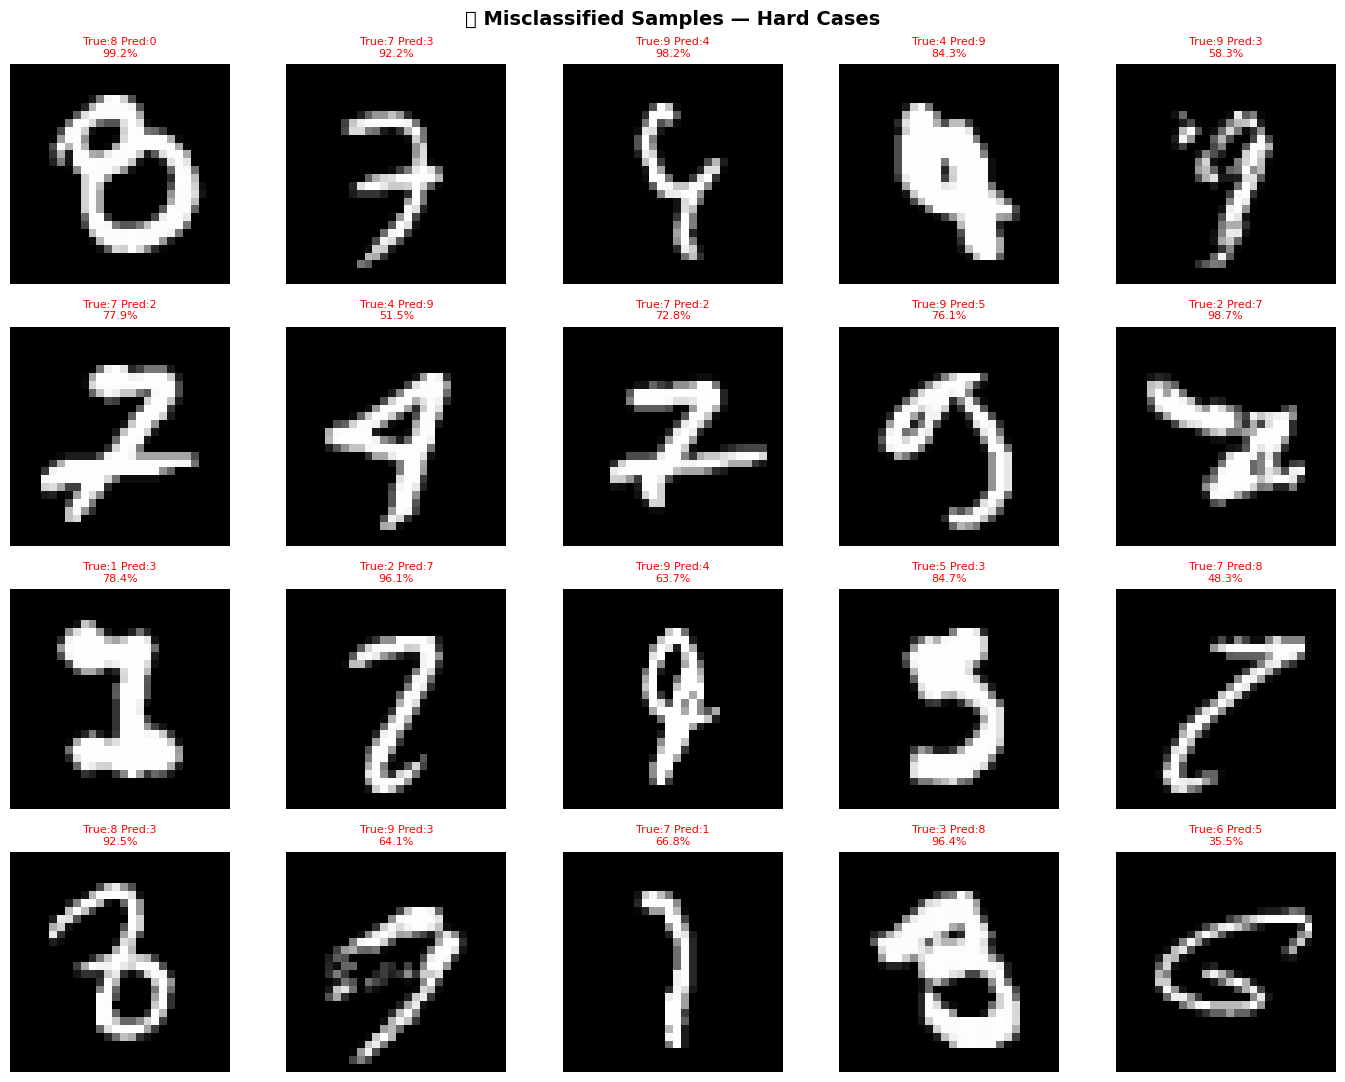

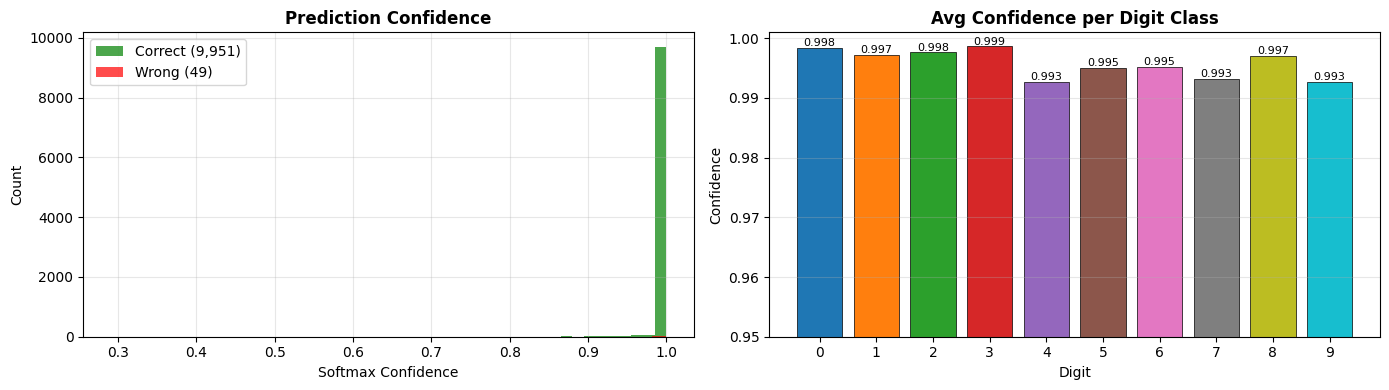

In [ ]:
# ─────────────────────────────────────────────────
# STEP 9: Predict on Sample Test Images
# ─────────────────────────────────────────────────

confidence   = np.max(y_pred_probs, axis=1)
correct_mask = (y_pred == y_true)

# --- Correct predictions ---
sample_c = np.random.choice(np.where(correct_mask)[0], 20, replace=False)
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('✅ Correct Predictions (20 Random Samples)', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flat, sample_c):
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f"True:{y_true[idx]} Pred:{y_pred[idx]}\n{confidence[idx]*100:.1f}%",
                 fontsize=8, color='green')
    ax.axis('off')
plt.tight_layout(); plt.show()

# --- Misclassified images ---
wrong_idx = np.where(~correct_mask)[0]
print(f"❌ Misclassified: {len(wrong_idx)} / {len(y_true)} ({len(wrong_idx)/len(y_true)*100:.2f}%)")
sample_w = np.random.choice(wrong_idx, min(20, len(wrong_idx)), replace=False)
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('❌ Misclassified Samples — Hard Cases', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flat, sample_w):
    ax.imshow(X_test_raw[idx], cmap='gray')
    ax.set_title(f"True:{y_true[idx]} Pred:{y_pred[idx]}\n{confidence[idx]*100:.1f}%",
                 fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout(); plt.show()

# --- Confidence distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(confidence[correct_mask],  bins=40, color='green', alpha=0.7, label=f'Correct ({correct_mask.sum():,})')
axes[0].hist(confidence[~correct_mask], bins=40, color='red',   alpha=0.7, label=f'Wrong ({(~correct_mask).sum():,})')
axes[0].set_title('Prediction Confidence', fontweight='bold')
axes[0].set_xlabel('Softmax Confidence'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

pcc  = [confidence[y_true == d].mean() for d in range(10)]
bars = axes[1].bar(range(10), pcc, color=plt.cm.tab10(np.linspace(0,1,10)),
                    edgecolor='black', linewidth=0.5)
axes[1].set_title('Avg Confidence per Digit Class', fontweight='bold')
axes[1].set_xlabel('Digit'); axes[1].set_ylabel('Confidence')
axes[1].set_xticks(range(10)); axes[1].set_ylim([0.95, 1.001])
for bar, val in zip(bars, pcc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                 f'{val:.3f}', ha='center', fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

In [ ]:
# ─────────────────────────────────────────────────
# STEP 10: Save Model + Final Summary
# ─────────────────────────────────────────────────

# Save full model (architecture + weights + optimizer)
model.save('mnist_cnn_model.keras')
print("✅ Full model saved  → mnist_cnn_model.keras")

model.save_weights('mnist_cnn_weights.weights.h5')
print("✅ Weights saved     → mnist_cnn_weights.weights.h5")
print("\n💡 Reload:  loaded_model = keras.models.load_model('mnist_cnn_model.keras')")

# Final summary
print("\n" + "=" * 60)
print("  Q4 — HANDWRITTEN DIGIT RECOGNITION | FINAL SUMMARY")
print("=" * 60)
print(f"  Dataset          : MNIST (60,000 train / 10,000 test)")
print(f"  Classes          : 10  (digits 0–9)")
print(f"  Model            : CNN — Conv2D×4 + Dense + BN + Dropout")
print(f"  Framework        : TensorFlow {tf.__version__}")
print("-" * 60)
print(f"  Total Parameters : {model.count_params():,}")
print(f"  Optimizer        : Adam  |  Loss: Categorical Crossentropy")
print(f"  Epochs Trained   : {len(history.history['loss'])} / {EPOCHS}")
print(f"  Batch Size       : {BATCH_SIZE}")
print("-" * 60)
print(f"  ✅ Test Accuracy  : {test_acc * 100:.2f}%")
print(f"  ✅ Test Loss      : {test_loss:.4f}")
print(f"  ✅ Correct        : {correct_mask.sum():,} / {len(y_true):,}")
print(f"  ❌ Misclassified  : {(~correct_mask).sum():,} / {len(y_true):,}")
print("=" * 60)

✅ Full model saved  → mnist_cnn_model.keras
✅ Weights saved     → mnist_cnn_weights.weights.h5

💡 Reload:  loaded_model = keras.models.load_model('mnist_cnn_model.keras')

  Q4 — HANDWRITTEN DIGIT RECOGNITION | FINAL SUMMARY
  Dataset          : MNIST (60,000 train / 10,000 test)
  Classes          : 10  (digits 0–9)
  Model            : CNN — Conv2D×4 + Dense + BN + Dropout
  Framework        : TensorFlow 2.19.0
------------------------------------------------------------
  Total Parameters : 872,426
  Optimizer        : Adam  |  Loss: Categorical Crossentropy
  Epochs Trained   : 10 / 10
  Batch Size       : 256
------------------------------------------------------------
  ✅ Test Accuracy  : 99.51%
  ✅ Test Loss      : 0.0154
  ✅ Correct        : 9,951 / 10,000
  ❌ Misclassified  : 49 / 10,000
